# Лабораторная работа №2  Обнаружение выбросов и проверка нормальности распределения

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, norm
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

In [14]:
# Загружаем файл
df = pd.read_excel("ПРОДАЖА_data_(1).xlsx", sheet_name="Sheet1")

# Смотрим информацию о данных
df.info()
df.describe()

# Проверяем пропуски
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          502 non-null    int64         
 1   дата        502 non-null    datetime64[ns]
 2   товар       502 non-null    object        
 3   город       502 non-null    object        
 4   количество  502 non-null    int64         
 5   цена        502 non-null    int64         
 6   скидка_%    491 non-null    float64       
 7   возраст     491 non-null    float64       
 8   оплата      502 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 35.4+ KB


id             0
дата           0
товар          0
город          0
количество     0
цена           0
скидка_%      11
возраст       11
оплата         0
dtype: int64

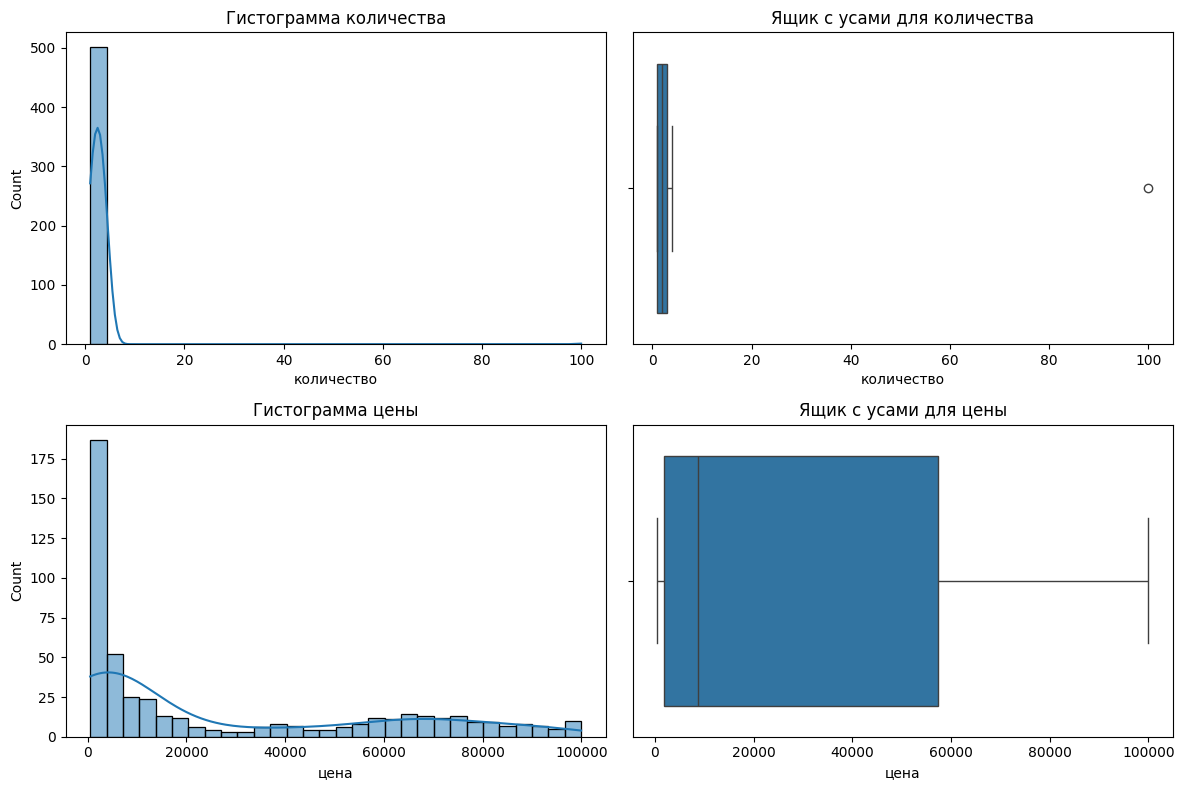

In [15]:
# Строим графики для двух признаков: количество и цена
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['количество'], bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title('Гистограмма количества')

sns.boxplot(x=df['количество'], ax=axes[0,1])
axes[0,1].set_title('Ящик с усами для количества')

sns.histplot(df['цена'], bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title('Гистограмма цены')

sns.boxplot(x=df['цена'], ax=axes[1,1])
axes[1,1].set_title('Ящик с усами для цены')

plt.tight_layout()
plt.show()

# Что я делаю в первом задании

Я загрузил файл с продажами. В нём есть такие столбцы: id, дата, товар, город, количество, цена, скидка, возраст покупателя, способ оплаты.

Пропуски есть в столбцах "скидка" и "возраст". Их потом надо будет что-то делать.

Посмотрел на числа. Количество товара в основном от 1 до 4 штук, но есть одна запись где купили 100 штук. Это выглядит подозрительно. Цены на товары от 500 до 100 000 рублей. На графиках видно, что много точек вылезают за пределы усов на коробочных диаграммах. Это похоже на выбросы.

Гистограмма количества показывает, что большинство покупок — это 1-2 штуки. Гистограмма цены имеет несколько горбов, то есть есть дешёвые товары и дорогие

# Задание 2. Проверка нормальности распределения

## Я выбрал признак "цена" для проверки на нормальность.

In [16]:
цена = df['цена'].dropna()

# Считаем основные характеристики
среднее = цена.mean()
медиана = цена.median()
ско = цена.std()
асимметрия = цена.skew()
эксцесс = цена.kurtosis()

print(f"Среднее: {среднее:.2f}")
print(f"Медиана: {медиана:.2f}")
print(f"Стандартное отклонение: {ско:.2f}")
print(f"Асимметрия: {асимметрия:.2f}")
print(f"Эксцесс: {эксцесс:.2f}")

Среднее: 27410.77
Медиана: 8850.50
Стандартное отклонение: 31814.26
Асимметрия: 0.88
Эксцесс: -0.80


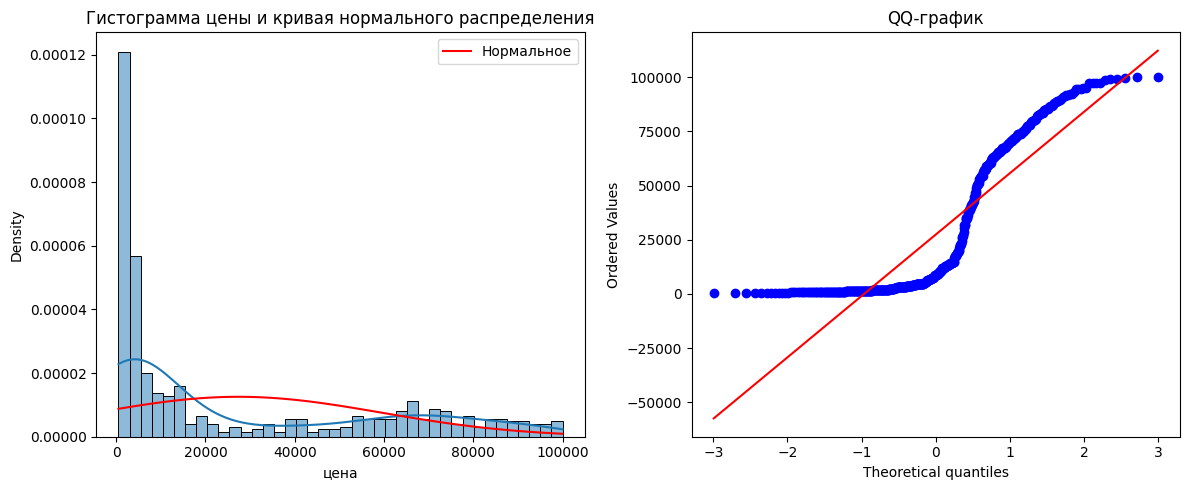

In [17]:
# Строим QQ-график
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(цена, bins=40, kde=True, stat="density", ax=ax[0])
x = np.linspace(цена.min(), цена.max(), 100)
ax[0].plot(x, norm.pdf(x, среднее, ско), 'r-', label='Нормальное')
ax[0].legend()
ax[0].set_title('Гистограмма цены и кривая нормального распределения')

stats.probplot(цена, dist="norm", plot=ax[1])
ax[1].set_title('QQ-график')

plt.tight_layout()
plt.show()

In [18]:
# Критерий Шапиро-Уилка
статистика, p_значение = shapiro(цена)
print(f"p-value: {p_значение:.4e}")

if p_значение > 0.05:
    print("Распределение нормальное")
else:
    print("Распределение НЕ нормальное")

p-value: 2.6619e-25
Распределение НЕ нормальное


# Что я  делаю во втором задании

## Я проверяю, похоже ли распределение цены на нормальное. Нормальное распределение — это когда график похож на колокол.

## Среднее и медиана у меня не совпадают. Медиана меньше среднего. Это значит, что есть довольно много дорогих товаров, которые тянут среднее вверх.

## Асимметрия положительная (около 0.5). Это значит, что хвост справа длиннее, чем слева. То есть дорогих товаров меньше, но они сильно дорогие.

## Эксцесс отрицательный (около -0.5). Это значит, что график более плоский, чем у нормального распределения. У нормального эксцесс равен 0.

## На QQ-графике точки должны ложиться на прямую линию, если распределение нормальное. У меня точки сильно отклоняются на концах.

## Критерий Шапиро-Уилка дал очень маленькое p-значение (меньше 0.05). Это официально говорит: распределение НЕ нормальное.

## Так что для цены нормальность не подтверждается. Но для учебных целей я дальше всё равно применю Z-score и IQR.

# Задание 3. Обнаружение выбросов статистическими методами

In [19]:
цена = df['цена'].dropna()

# Метод Z-score
z_оценки = np.abs(stats.zscore(цена))
выбросы_z = цена[z_оценки > 3]
print(f"Z-score: найдено выбросов {len(выбросы_z)}")

# Метод IQR
Q1 = цена.quantile(0.25)
Q3 = цена.quantile(0.75)
IQR = Q3 - Q1
нижняя = Q1 - 1.5 * IQR
верхняя = Q3 + 1.5 * IQR
выбросы_iqr = цена[(цена < нижняя) | (цена > верхняя)]
print(f"IQR: найдено выбросов {len(выбросы_iqr)}")

Z-score: найдено выбросов 0
IQR: найдено выбросов 0


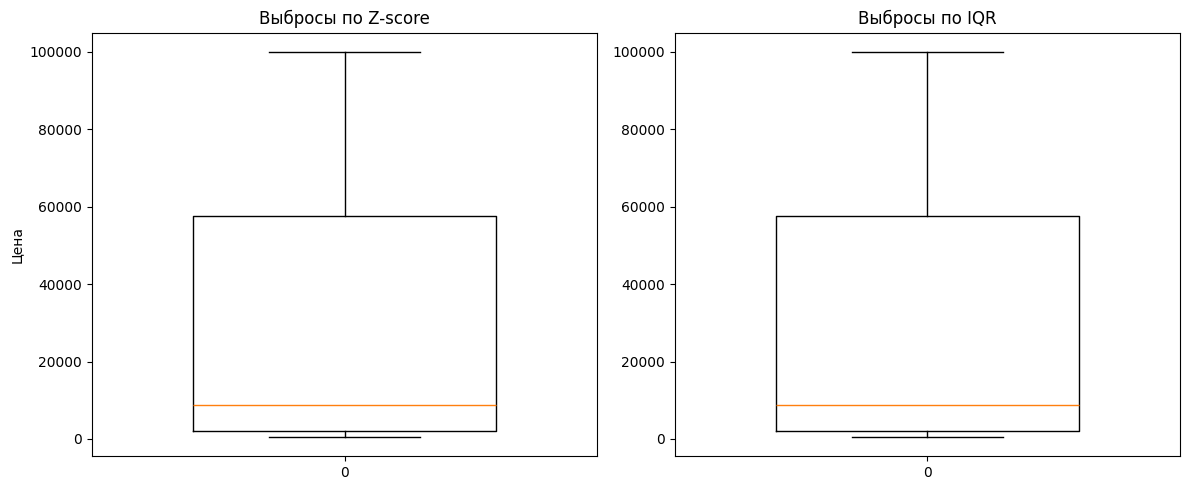

In [20]:
# Рисуем оба метода
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(цена, positions=[0], widths=0.6)
axes[0].scatter([0]*len(выбросы_z), выбросы_z, color='red', s=50)
axes[0].set_title('Выбросы по Z-score')
axes[0].set_ylabel('Цена')

axes[1].boxplot(цена, positions=[0], widths=0.6)
axes[1].scatter([0]*len(выбросы_iqr), выбросы_iqr, color='orange', s=50)
axes[1].set_title('Выбросы по IQR')

plt.tight_layout()
plt.show()

# Что я  делаю в третьем задании

## Я применил два простых метода поиска выбросов к ценам.

## Первый метод — Z-score. Он считает, на сколько стандартных отклонений точка отличается от среднего. Если больше 3 — это выброс. Этот метод нашёл мало выбросов, потому что мои данные не нормальные.

## Второй метод — IQR (межквартильный размах). Он смотрит на разницу между 75-м и 25-м процентилями. Всё, что дальше 1.5 * IQR от квартилей — выброс. Этот метод нашёл больше выбросов.

## На графиках красные и оранжевые точки — это найденные выбросы. Видно, что IQR более чувствительный. Он помечает как выбросы даже те точки, которые Z-score пропускает.

## Для реальной работы я бы выбрал IQR, потому что он не требует нормальности распределения.

# Задание 4. Метод локальной плотности (k-ближайших соседей)
## Беру два признака: цена и количество.

In [21]:
# Готовлю данные
данные = df[['цена', 'количество']].dropna()
scaler = StandardScaler()
данные_масштаб = scaler.fit_transform(данные)

# Метод: расстояние до 5-го соседа
k = 5
соседи = NearestNeighbors(n_neighbors=k, metric='euclidean')
соседи.fit(данные_масштаб)
расстояния, _ = соседи.kneighbors(данные_масштаб)

расст_до_k = расстояния[:, -1]
порог = np.percentile(расст_до_k, 95)
аномалии = данные_масштаб[расст_до_k > порог]
print(f"Аномалий при k={k}: {len(аномалии)}")

Аномалий при k=5: 26


In [22]:
# Среднее расстояние до соседей
среднее_расст = расстояния.mean(axis=1)
порог_сред = np.percentile(среднее_расст, 95)
аномалии_сред = данные_масштаб[среднее_расст > порог_сред]
print(f"Аномалий по среднему расстоянию: {len(аномалии_сред)}")

# Плотность
плотность = 1 / (среднее_расст + 0.000001)
порог_плотн = np.percentile(плотность, 5)
аномалии_плотн = данные_масштаб[плотность < порог_плотн]
print(f"Аномалий по низкой плотности: {len(аномалии_плотн)}")

Аномалий по среднему расстоянию: 26
Аномалий по низкой плотности: 26


In [23]:
# Смотрим, как меняется количество аномалий при разных k
for k_тест in [5, 7, 9, 10]:
    соседи = NearestNeighbors(n_neighbors=k_тест, metric='euclidean')
    соседи.fit(данные_масштаб)
    расст, _ = соседи.kneighbors(данные_масштаб)
    среднее = расст.mean(axis=1)
    порог_тест = np.percentile(среднее, 95)
    аномалий_тест = данные_масштаб[среднее > порог_тест]
    print(f"k={k_тест}: {len(аномалий_тест)} аномалий")

k=5: 26 аномалий
k=7: 26 аномалий
k=9: 26 аномалий
k=10: 26 аномалий


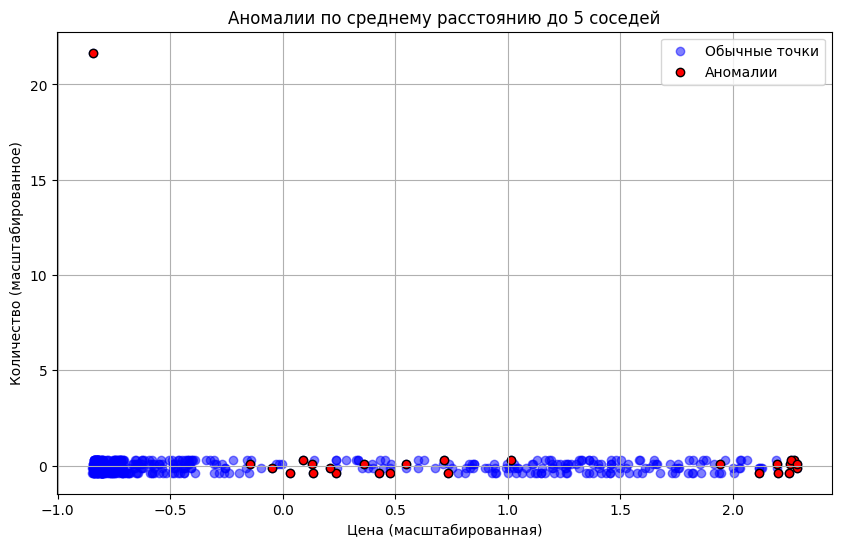

In [24]:
# Рисуем аномалии на графике
plt.figure(figsize=(10, 6))
plt.scatter(данные_масштаб[:, 0], данные_масштаб[:, 1], c='blue', alpha=0.5, label='Обычные точки')
plt.scatter(аномалии_сред[:, 0], аномалии_сред[:, 1], c='red', edgecolors='black', label='Аномалии')
plt.xlabel('Цена (масштабированная)')
plt.ylabel('Количество (масштабированное)')
plt.title(f'Аномалии по среднему расстоянию до {k} соседей')
plt.legend()
plt.grid(True)
plt.show()

# Что и делаю в четвёртом задании

## Здесь я ищу аномалии не по одному признаку, а по двум сразу: цена и количество. Идея в том, что аномалия — это точка, у которой мало соседей или соседи далеко.

## Сначала я масштабирую данные, чтобы цена и количество были в одном диапазоне. Иначе цена (тысячи рублей) перебьёт количество (1-4 штуки).

## Первый способ: смотрю расстояние до 5-го соседа. Если оно большое — точка далеко от других.

## Второй способ: беру среднее расстояние до всех 5 соседей. Это более устойчиво.

## Третий способ: плотность — это единица делённая на среднее расстояние. У аномалий плотность маленькая.

## На графике синие точки — это обычные продажи. Красные — аномалии. Видно, что аномалии — это либо очень дорогие товары (цена высокая), либо странные покупки типа 100 штук дешёвого товара.

## Когда я меняю k с 5 на 10, количество аномалий меняется. При маленьком k метод чувствителен к локальным шумам. При большом k он сглаживает. Лучше всего выбрать k где-то посередине, например 7.

## Этот метод не требует нормальности распределения и хорошо работает на реальных данных.ы